In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn ta tensorflow

Note: you may need to restart the kernel to use updated packages.


In [35]:
pip install xgboost scikit-learn


Note: you may need to restart the kernel to use updated packages.


✅ MAE: ₹453.39
✅ RMSE: ₹670.77
✅ R² Score: 0.9993
🎯 RMSE ≈ MAE × 1.2 → 670.77 vs 544.07
📉 Relative RMSE (% of avg test price): 1.06%


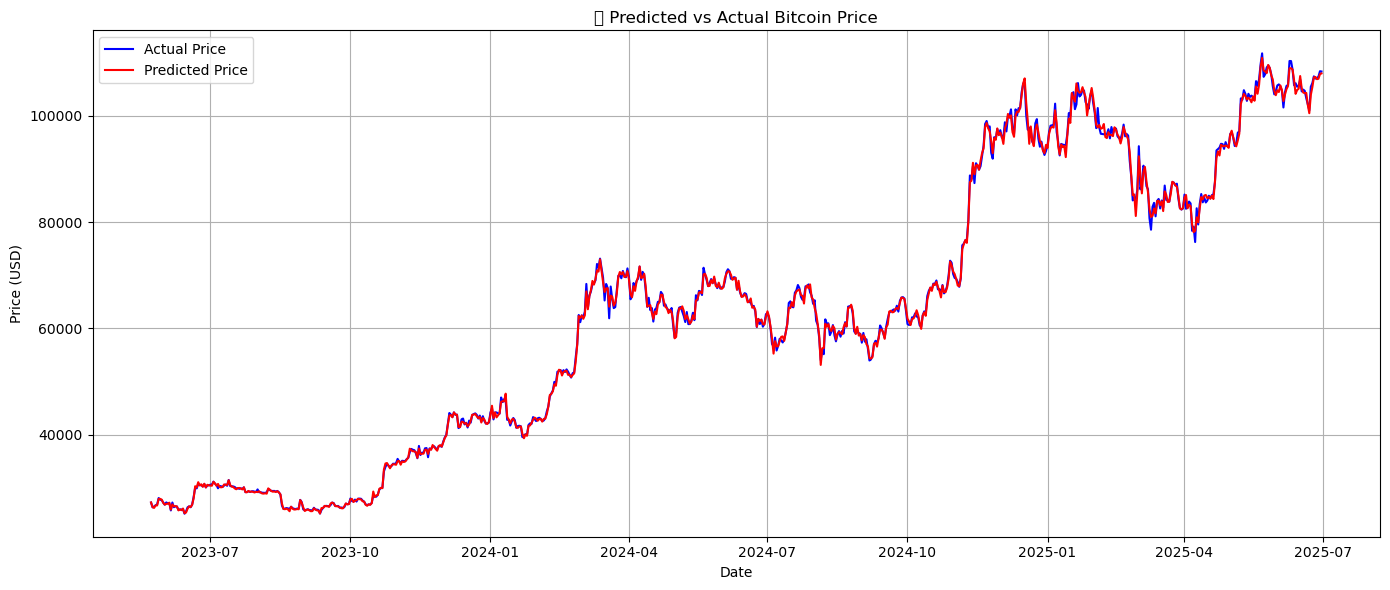

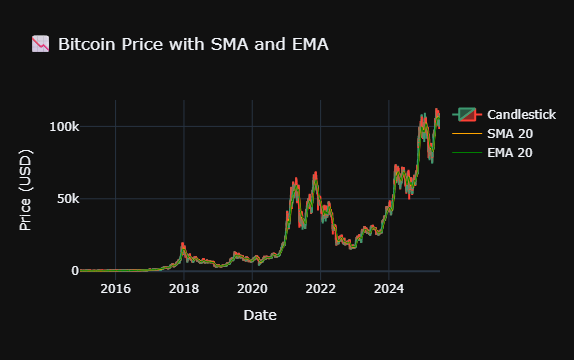

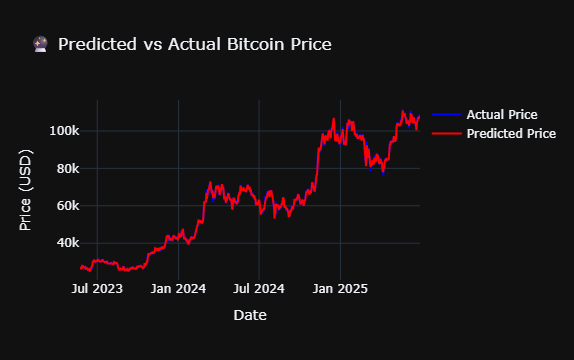

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

# --------------------------------------
# 📥 1. Load & Preprocess BTC Data
# --------------------------------------
btc_df = pd.read_csv("Bitstamp_BTCUSD_d.csv", skiprows=1)  # ← Skip header link row

# ✅ Convert date column
btc_df['date'] = pd.to_datetime(btc_df['date'])
btc_df.set_index('date', inplace=True)
btc_df.sort_index(inplace=True)

# ✅ Rename for simplicity
btc_df.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'Volume USD': 'Volume'
}, inplace=True)

# --------------------------------------
# 🧹 2. Feature Engineering
# --------------------------------------
btc_df['SMA_20'] = btc_df['Close'].rolling(window=20).mean()
btc_df['EMA_20'] = btc_df['Close'].ewm(span=20, adjust=False).mean()
btc_df['SMA_ratio'] = btc_df['Close'] / btc_df['SMA_20']
btc_df['EMA_ratio'] = btc_df['Close'] / btc_df['EMA_20']
btc_df['Price_Change'] = btc_df['Close'].pct_change()

btc_df.dropna(inplace=True)

# --------------------------------------
# 📊 3. Prepare Features & Target
# --------------------------------------
features = ['Open', 'High', 'Low', 'Volume', 'SMA_ratio', 'EMA_ratio', 'Price_Change']
target = 'Close'

X = btc_df[features]
y = btc_df[target]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------
# 🔀 4. Train-Test Split
# --------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

# --------------------------------------
# 🤖 5. Train the Model
# --------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# --------------------------------------
# 📈 6. Make Predictions
# --------------------------------------
y_pred = model.predict(X_test)

# --------------------------------------
# ✅ 7. Evaluation
# --------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"✅ MAE: ₹{mae:.2f}")
print(f"✅ RMSE: ₹{rmse:.2f}")
print(f"✅ R² Score: {r2:.4f}")
print(f"🎯 RMSE ≈ MAE × 1.2 → {rmse:.2f} vs {mae * 1.2:.2f}")
print(f"📉 Relative RMSE (% of avg test price): {rmse / y_test.mean() * 100:.2f}%")

# --------------------------------------
# 📊 8. Plot Predictions vs Actual
# --------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Actual Price', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Price', color='red')
plt.title('🔮 Predicted vs Actual Bitcoin Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
import plotly.graph_objects as go

# --------------------------------------
# 📉 9. Candlestick Chart with SMA/EMA
# --------------------------------------
candlestick = go.Candlestick(
    x=btc_df.index,
    open=btc_df['Open'],
    high=btc_df['High'],
    low=btc_df['Low'],
    close=btc_df['Close'],
    name='Candlestick'
)

sma_line = go.Scatter(
    x=btc_df.index,
    y=btc_df['SMA_20'],
    line=dict(color='orange', width=1),
    name='SMA 20'
)

ema_line = go.Scatter(
    x=btc_df.index,
    y=btc_df['EMA_20'],
    line=dict(color='green', width=1),
    name='EMA 20'
)

fig1 = go.Figure(data=[candlestick, sma_line, ema_line])
fig1.update_layout(
    title='📉 Bitcoin Price with SMA and EMA',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    xaxis_rangeslider_visible=False,
    template='plotly_dark'
)
fig1.show()

# --------------------------------------
# 📈 10. Actual vs Predicted (Interactive)
# --------------------------------------
pred_line = go.Scatter(
    x=y_test.index,
    y=y_pred,
    mode='lines',
    name='Predicted Price',
    line=dict(color='red')
)

actual_line = go.Scatter(
    x=y_test.index,
    y=y_test,
    mode='lines',
    name='Actual Price',
    line=dict(color='blue')
)

fig2 = go.Figure(data=[actual_line, pred_line])
fig2.update_layout(
    title='🔮 Predicted vs Actual Bitcoin Price',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_dark'
)
fig2.show()



In [41]:


!pip install plotly


In [45]:
btc_df['RSI_14'] = btc_df['Close'].rolling(14).apply(
    lambda x: 100 - (100 / (1 + (x.pct_change().mean() / x.pct_change().std())))
)

from ta.trend import MACD
macd = MACD(close=btc_df['Close'])
btc_df['MACD'] = macd.macd()
btc_df['MACD_signal'] = macd.macd_signal()


In [47]:
btc_df['Volatility'] = btc_df['Close'].rolling(window=20).std()


In [49]:
btc_df['BB_upper'] = btc_df['SMA_20'] + 2 * btc_df['Volatility']
btc_df['BB_lower'] = btc_df['SMA_20'] - 2 * btc_df['Volatility']


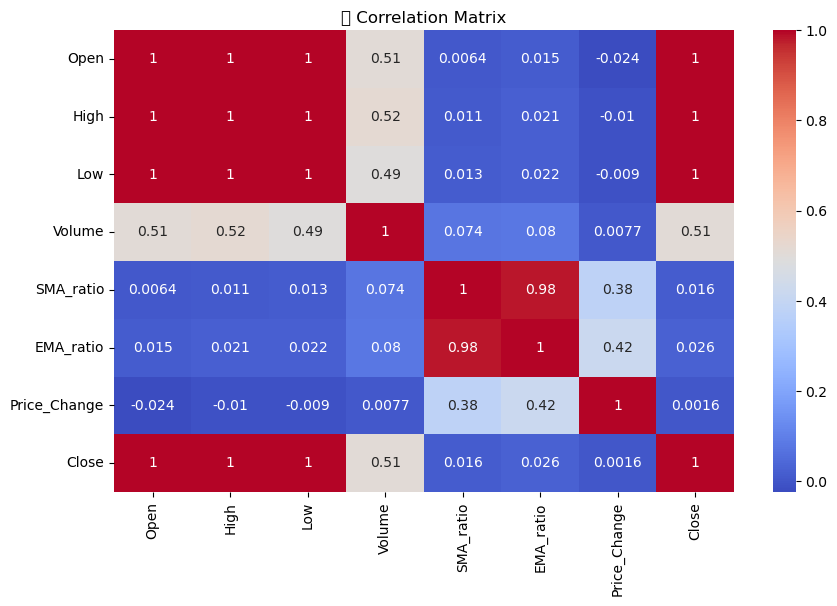

In [51]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(btc_df[features + ['Close']].corr(), annot=True, cmap='coolwarm')
plt.title('🔍 Correlation Matrix')
plt.show()


In [59]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(btc_df['Close'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')


ADF Statistic: 0.30849596163383736
p-value: 0.9777309358160883


In [61]:
btc_df['DayOfWeek'] = btc_df.index.dayofweek
btc_df['Month'] = btc_df.index.month
btc_df['Day'] = btc_df.index.day


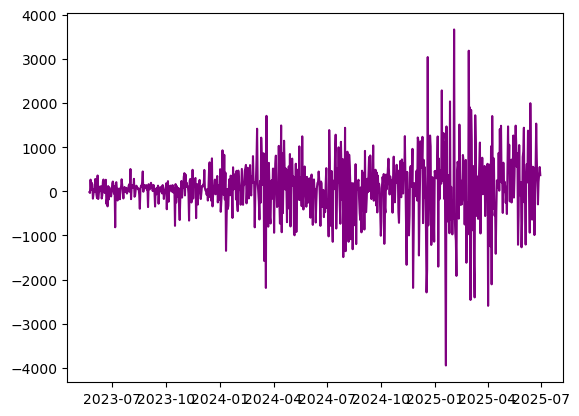

In [63]:
plt.plot(y_test.index, y_test - y_pred, label='Prediction Error', color='purple')


In [65]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)


RandomForestRegressor()

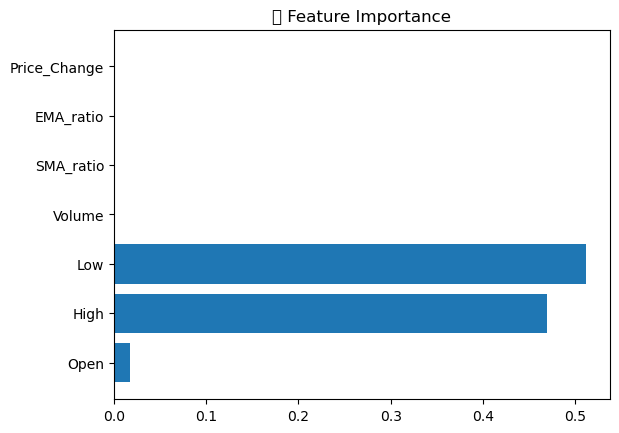

In [67]:
importances = model.feature_importances_
plt.barh(features, importances)
plt.title('🔍 Feature Importance')
plt.show()
